# Model Building

In this notebook, we train and compare multiple machine learning models to identify the best-performing model for predictive maintenance.

In [2]:
# Import the required libraries for model training and evaluation
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [3]:
# Load the engineered dataset and saved preprocessing pipeline
df = pd.read_csv("../data/processed/engineered_data.csv")

preprocessor = joblib.load("../artifacts/preprocessor.pkl")

df.head()

,Date,System,Control,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic,Year,Month,Day,Day_of_Week,Quarter,Temperature_Difference,Power_Index
0,2014-04-15 11:56:00,0,C,M,300.064358,310.033081,1541.242402,42.8,0.00000,No failure,2014,4,15,1,2,9.968723,65965.174787
1,2014-04-12 16:09:00,0,A,L,298.200000,308.700000,1408.000000,39.9,110.52424,No failure,2014,4,12,5,2,10.500000,56179.200000
2,2014-04-13 01:13:00,0,A,L,298.100000,308.500000,1498.000000,39.9,110.52424,No failure,2014,4,13,6,2,10.400000,59770.200000
3,2014-07-24 20:35:00,0,B,L,300.064358,310.033081,1433.000000,39.5,110.52424,No failure,2014,7,24,3,3,9.968723,56603.500000
4,2014-07-22 01:31:00,0,C,L,300.064358,310.033081,1541.242402,40.0,9.00000,No failure,2014,7,22,1,3,9.968723,61649.696062


In [4]:
df.columns

Index(['Date', 'System', 'Control', 'Type', 'Air temperature (K)',
       'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)',
       'Tool wear (min)', 'Diagnostic', 'Year', 'Month', 'Day', 'Day_of_Week',
       'Quarter', 'Temperature_Difference', 'Power_Index'],
      dtype='str')

In [10]:
# Separate input features and target variable by removing unnecessary columns
from sklearn.preprocessing import LabelEncoder

# Separate input features
X = df.drop(columns=["Date", "Diagnostic"])

# Encode the target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Diagnostic"])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nEncoded Classes:")
for index, label in enumerate(label_encoder.classes_):
    print(f"{index} -> {label}")

Feature Shape: (10000, 15)
Target Shape: (10000,)

Encoded Classes:
0 -> Heat Dissipation Failure
1 -> No failure
2 -> Overstrain Failure
3 -> Power Failure
4 -> Random Failures
5 -> Tool Wear Failure


In [11]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (8000, 15)
Testing Features: (2000, 15)
Training Target: (8000,)
Testing Target: (2000,)


In [12]:
# Apply the saved preprocessing pipeline to the training and testing data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (8000, 138)
Processed Testing Shape: (2000, 138)


### Observation

The saved preprocessing pipeline was successfully applied to both the training and testing datasets, preparing them for model training.

In [13]:
# Create a dictionary of machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

In [17]:
# Train each model, make predictions, and store the evaluation results
# 
results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train_processed, y_train)

    # Make predictions
    y_pred = model.predict(X_test_processed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9850
Decision Tree Accuracy: 0.9895
Random Forest Accuracy: 0.9925
K-Nearest Neighbors Accuracy: 0.9795
Support Vector Machine Accuracy: 0.9895
Gradient Boosting Accuracy: 0.9890
XGBoost Accuracy: 0.9910


In [16]:
# Create a comparison table of model accuracies
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy
0,Random Forest,0.9925
1,XGBoost,0.9910
2,Decision Tree,0.9895
3,Support Vector Machine,0.9895
4,Gradient Boosting,0.9890
5,Logistic Regression,0.9850
6,K-Nearest Neighbors,0.9795


In [18]:
# Evaluate the Random Forest model using detailed classification metrics
best_model = models["Random Forest"]

y_pred = best_model.predict(X_test_processed)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        21
              No failure       0.99      1.00      1.00      1930
      Overstrain Failure       1.00      0.85      0.92        20
           Power Failure       1.00      1.00      1.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      2000
               macro avg       0.67      0.64      0.65      2000
            weighted avg       0.99      0.99      0.99      2000



c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

### Observation

The Random Forest model was evaluated using precision, recall, F1-score, and support to understand its performance for each failure category.

In [19]:
# Evaluate the XGBoost model using detailed classification metrics
xgb_model = models["XGBoost"]

y_pred_xgb = xgb_model.predict(X_test_processed)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.95      1.00      0.98        21
              No failure       0.99      1.00      1.00      1930
      Overstrain Failure       1.00      1.00      1.00        20
           Power Failure       1.00      1.00      1.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      2000
               macro avg       0.66      0.67      0.66      2000
            weighted avg       0.99      0.99      0.99      2000



c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

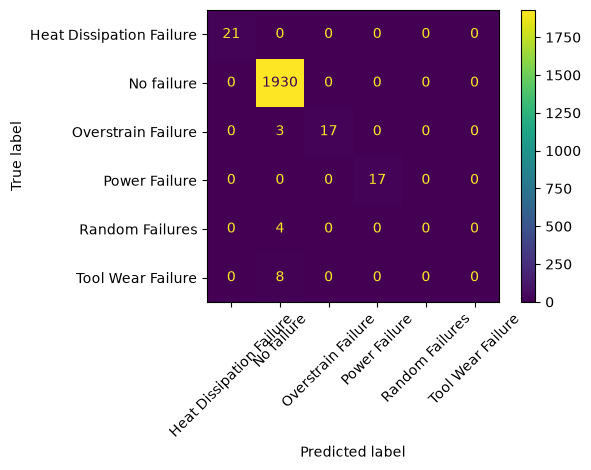

In [20]:
# Display the confusion matrix for the Random Forest model
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.tight_layout()
plt.show()

### Observation

The confusion matrix shows that the Random Forest model correctly classified most samples, including all Heat Dissipation, Power Failure, and No Failure instances. However, it struggled to identify the rare Random Failure and Tool Wear Failure classes, highlighting the impact of class imbalance in the dataset.

In [21]:
# Save the trained model and label encoder
joblib.dump(best_model, "../artifacts/best_model.pkl")
joblib.dump(label_encoder, "../artifacts/label_encoder.pkl")

print("Model and label encoder saved successfully.")

Model and label encoder saved successfully.


## Final Observation

Multiple machine learning models were trained and evaluated on the predictive maintenance dataset.

Random Forest achieved the highest baseline accuracy and was selected as the final model. The evaluation also revealed that the model struggled to identify extremely rare failure classes due to class imbalance. These limitations will be addressed in the next stage through techniques such as SMOTE and hyperparameter tuning.